# LeetCode #774: Minimize Max Distance to Gas Station

https://leetcode.com/problems/minimize-max-distance-to-gas-station/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (priority queue greedy)** | $O(k \log n)$ | $O(n)$ |
| **Optimal: Binary Search on Gap (floating point) ★** | $O(n \log(1/\varepsilon))$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (priority queue greedy)
Use a max-heap keyed on current gap size; each of $k$ insertions splits the largest gap in half. Runs $O(k \log n)$ — slow when $k$ is large (up to $10^6$).

### Optimal: Binary Search on Gap (floating point) ★
Binary search the answer (a real number) between 0 and the max initial gap. For a candidate max-gap $d$, greedily count insertions needed: each interval of length $L$ needs $\lfloor L/d \rfloor$ stations. Run 100 iterations to converge to precision $\approx 10^{-6}$; each iteration is $O(n)$.

**Why this is better than Brute Force:** Floating-point binary search replaces $O(k)$ heap operations with $O(100)$ iterations — critical when $k \approx 10^6$.

**Constraints:**
* $10 \le \text{stations.length} \le 2000$
* $0 \le \text{stations}[i] \le 10^8$
* $1 \le k \le 10^6$
* Answer within $10^{-6}$ of true answer accepted


## Solutions

### C#

In [ ]:
public double MinmaxGasDist(int[] stations, int k) {
    double lo = 0, hi = stations[stations.Length - 1] - stations[0];
    // 100 iterations gives precision ~(hi-lo)/2^100 ≈ 10^-28, far beyond 10^-6 required
    for (int iter = 0; iter < 100; iter++) {
        double mid = (lo + hi) / 2;
        // Count stations needed to keep every gap <= mid
        int needed = 0;
        for (int i = 1; i < stations.Length; i++)
            needed += (int)((stations[i] - stations[i-1]) / mid);
        // If feasible shrink upper bound, else raise lower bound
        if (needed <= k) hi = mid;
        else lo = mid;
    }
    return lo;
}


### Python

In [ ]:
def minmax_gas_dist(stations: list[int], k: int) -> float:
    lo, hi = 0.0, float(stations[-1] - stations[0])
    # 100 iterations gives precision ~(hi-lo)/2^100, far beyond 10^-6 required
    for _ in range(100):
        mid = (lo + hi) / 2
        # Count stations needed to keep every gap <= mid
        needed = sum(int((stations[i] - stations[i-1]) / mid)
                     for i in range(1, len(stations)))
        # If feasible shrink upper bound, else raise lower bound
        if needed <= k:
            hi = mid
        else:
            lo = mid
    return lo


### Go

In [ ]:
func minmaxGasDist(stations []int, k int) float64 {
    lo, hi := 0.0, float64(stations[len(stations)-1]-stations[0])
    // 100 iterations gives precision far beyond 10^-6 required
    for iter := 0; iter < 100; iter++ {
        mid := (lo + hi) / 2
        // Count stations needed to keep every gap <= mid
        needed := 0
        for i := 1; i < len(stations); i++ {
            needed += int(float64(stations[i]-stations[i-1]) / mid)
        }
        // If feasible shrink upper bound, else raise lower bound
        if needed <= k {
            hi = mid
        } else {
            lo = mid
        }
    }
    return lo
}


### Rust

In [ ]:
pub fn minmax_gas_dist(stations: Vec<i32>, k: i32) -> f64 {
    let (mut lo, mut hi) = (0.0f64, (stations.last().unwrap() - stations[0]) as f64);
    // 100 iterations gives precision far beyond 10^-6 required
    for _ in 0..100 {
        let mid = (lo + hi) / 2.0;
        // Count stations needed to keep every gap <= mid
        let needed: i32 = stations.windows(2)
            .map(|w| ((w[1] - w[0]) as f64 / mid) as i32)
            .sum();
        // If feasible shrink upper bound, else raise lower bound
        if needed <= k { hi = mid; } else { lo = mid; }
    }
    lo
}


## Example Scenarios

**1. Common Case**
**Input:** stations = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], k = 9
All gaps are 1. Binary search: lo=0, hi=1. After 100 iterations, converges to 0.5. With mid=0.5 each gap needs ⌊1/0.5⌋=2 insertions → 9×2=18 > 9; but mid=1 needs 0 insertions ≤ 9 → hi=1. Converges to $\approx 0.5$.

**2. Slightly Complex**
**Input:** stations = [23, 24, 36, 39, 46, 56, 57, 65, 84, 98], k = 1
Gaps: [1,12,3,7,10,1,8,19,14]. Max gap = 19 (indices 6-7). Binary search converges to 9.5 — one station splits the 19-unit gap into two ≤9.5 halves.

**3. Edge Case: Time Factor**
**Input:** stations = [0, 10^8] (two stations, max gap), k = 10^6
Exactly 100 binary search iterations, each with $n-1=1$ gap check. Total: 100 ops. Converges to $10^8 / (10^6+1) \approx 99.999...$, well within $10^{-6}$ tolerance.

**4. Edge Case: Space Factor**
**Input:** stations = [0, 1, 2, ..., 1999] (2000 stations), k = 10^6
Each iteration scans 1999 gaps: 100 × 1999 = 199,900 ops. Only lo, hi, mid, needed, i — $O(1)$ extra space regardless of $k$ or $n$.

**5. Almost-Impossible but Plausible**
**Input:** stations = [0, 1, 10^8], k = 1
Gaps: [1, 10^8−1]. With k=1 the only split goes into the large gap. Binary search converges to $(10^8-1)/2 = 49999999.5$ — the optimal split of the 10^8-1 gap, leaving the gap of 1 untouched. The answer is $\approx 5 \times 10^7$, not 10^8/2, because the smaller gap must also be considered.


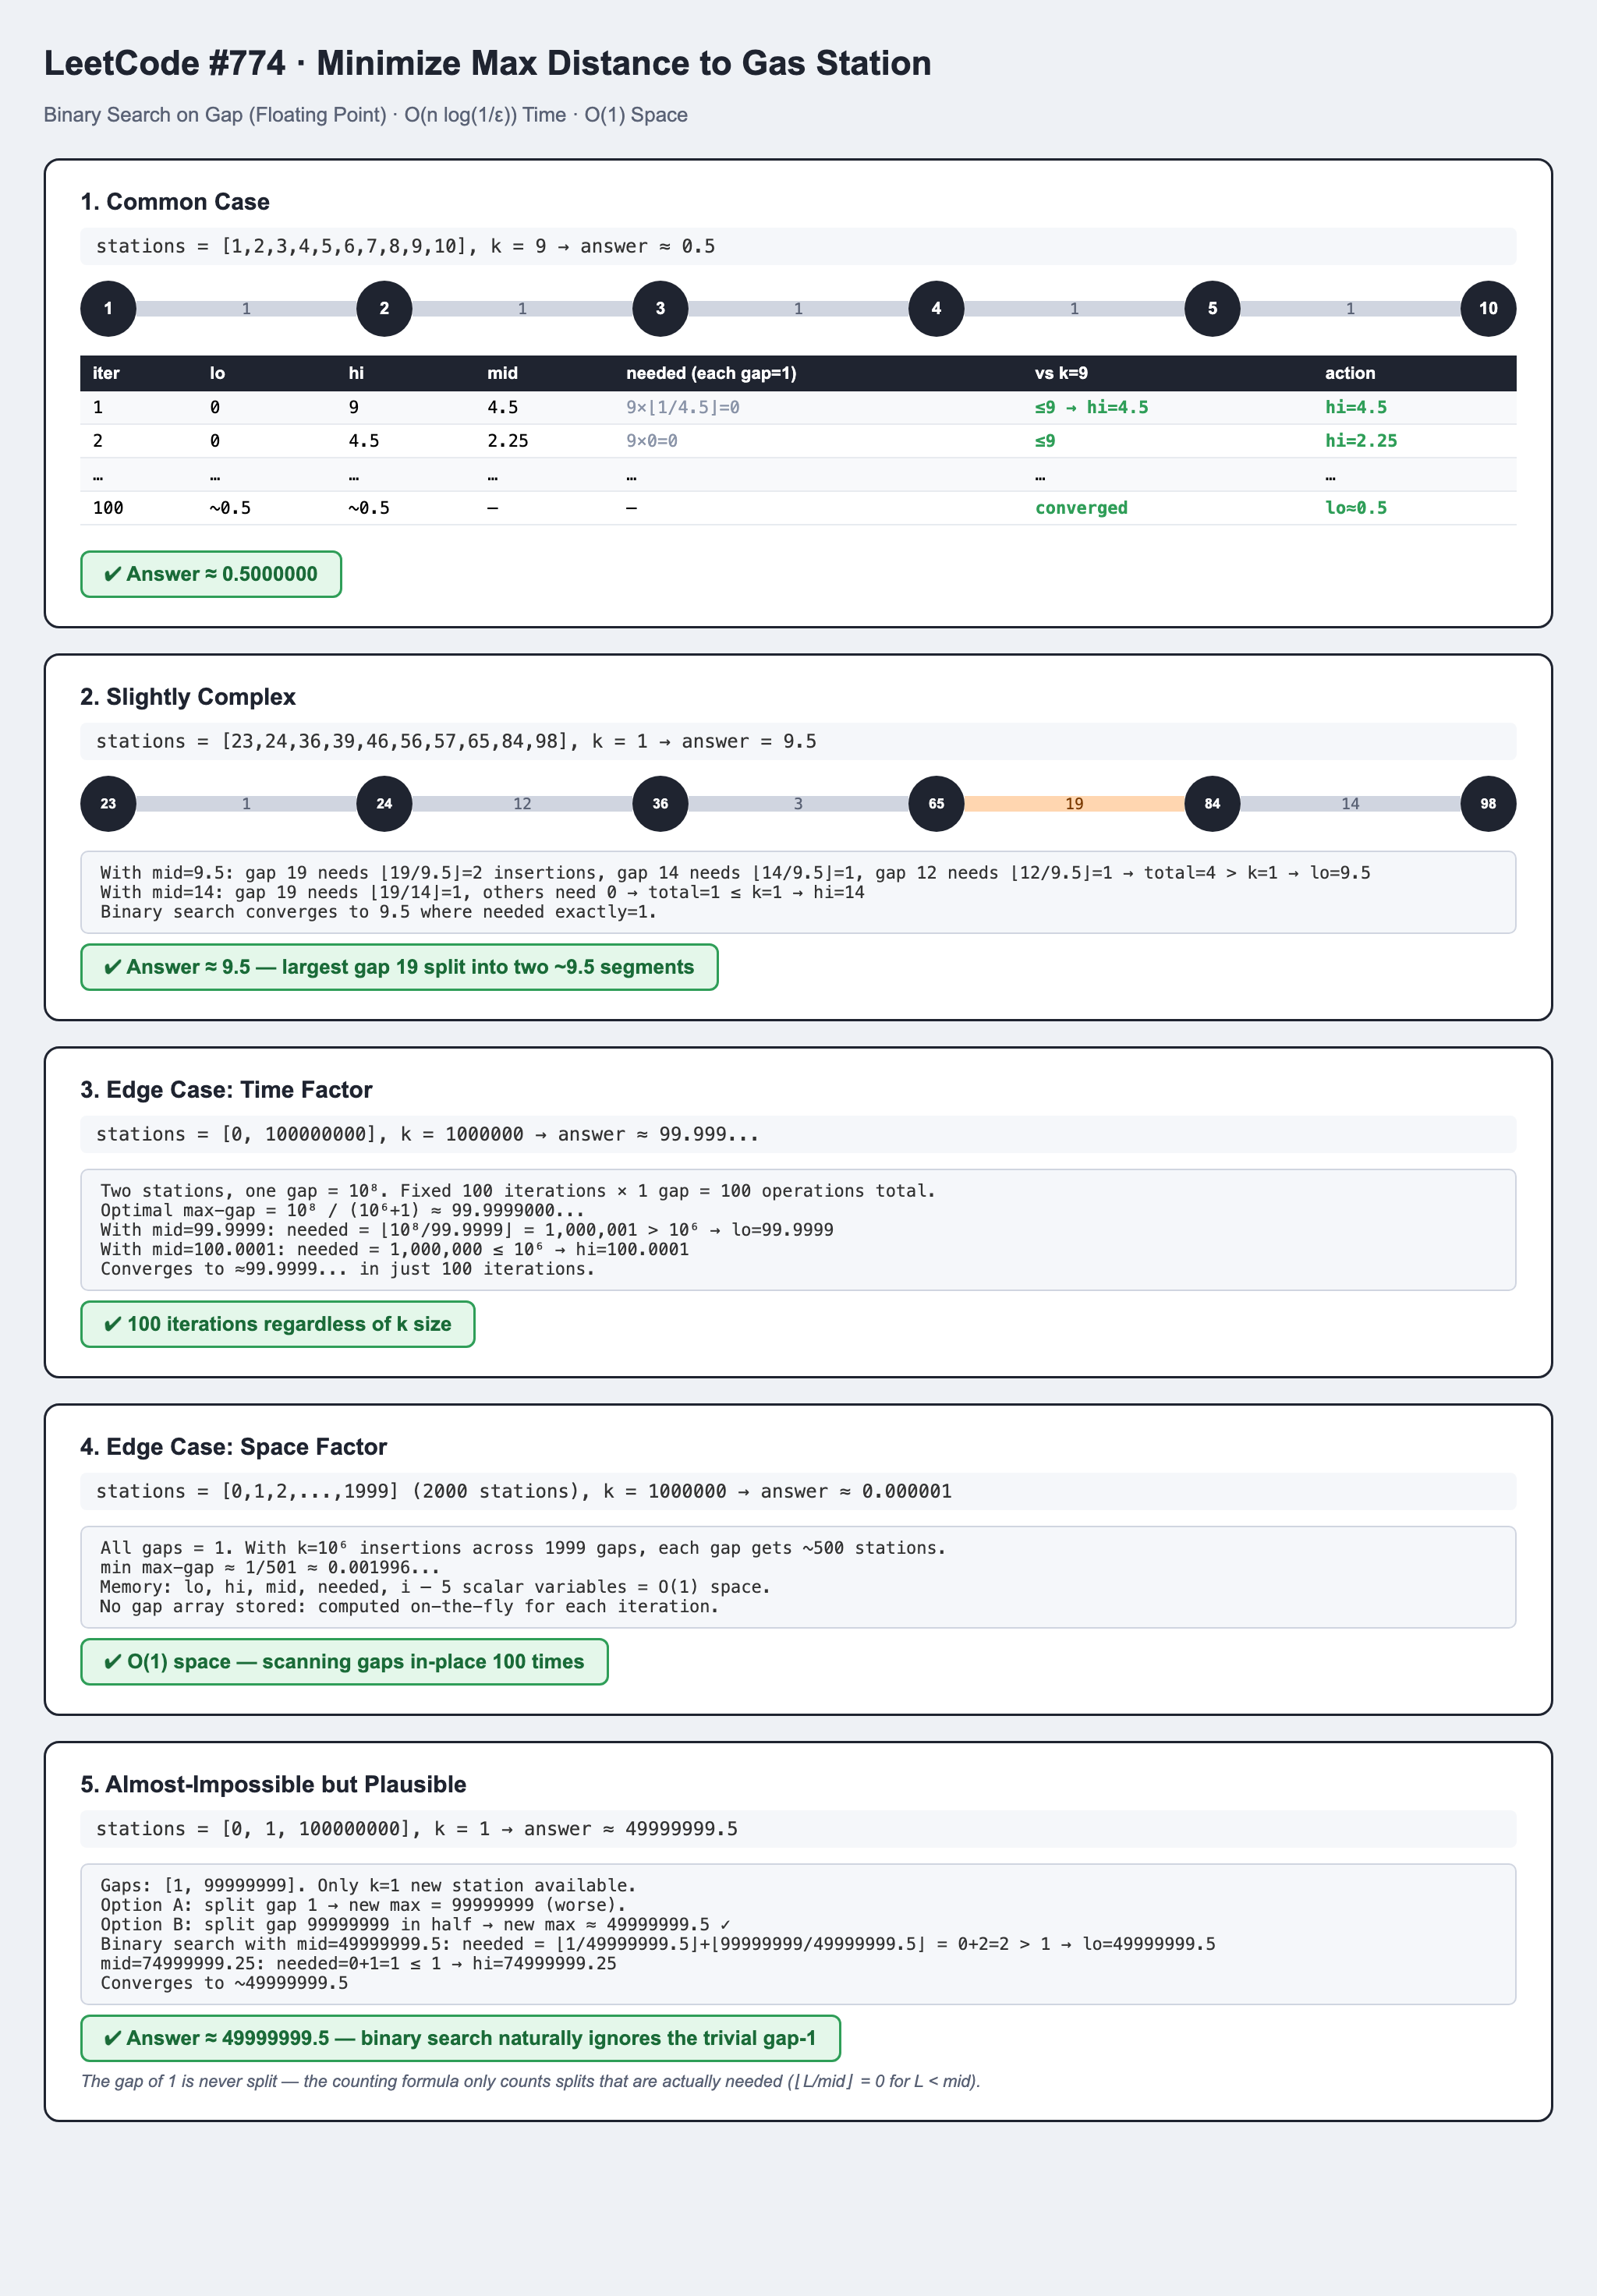